Intalación modelos iniciales para empezar el tunning

In [ ]:
!pip uninstall -y -q gradio gradio-client
!pip install -q unsloth unsloth_zoo trl
!pip install -q --no-cache-dir "transformers==5.5.0"

Hay que reiniciar la instancia despues de la instalación
Depues con lo siguiente confirmo que se instalo todo bien

In [ ]:
import unsloth
import torch, transformers, peft, trl
from transformers.models.auto.configuration_auto import CONFIG_MAPPING_NAMES

print("transformers ", transformers.__version__)
print("gemma4       ", 'gemma4' in CONFIG_MAPPING_NAMES)
print("trl          ", trl.__version__)
print("GPU          ", torch.cuda.get_device_name(0) if torch.cuda.is_available() else ">>> SIN GPU <<<")

aseguramos la conexión con DRIVE donde tengo mis fotos para hacerle TUNNING en al modelo

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Ahora definimos los valores a utilizar en todas las demas secciones

In [ ]:
MODELO_BASE      = "unsloth/gemma-4-E2B-it"

RESOLUCION       = 896
RECORTE_SUPERIOR = 1.0
EPOCAS           = 3
SEMILLA          = 42

# --- DÓNDE ESTÁN TUS DATOS (Google Drive) ---
BASE             = '/content/drive/MyDrive/dataset_facturas'
RUTA_JSON        = BASE + '/data.json'
RUTA_IMG_DRIVE   = BASE + '/imagenes'
RUTA_MODELO_LORA = BASE + '/modelo_facturas_lora'

RUTA_IMAGENES    = '/content/imagenes'
DIR_CHECKPOINTS  = '/content/outputs'

import os
from pathlib import Path
os.makedirs(DIR_CHECKPOINTS, exist_ok=True)
os.makedirs(RUTA_MODELO_LORA, exist_ok=True)
print("Configuración cargada.")

Confirmamos que los valores de JSON que puse en mi archivo data funcionen

In [ ]:
import json

with open(RUTA_JSON, encoding='utf-8') as f:
    datos = json.load(f)

print("Total de ejemplos:", len(datos))
print("Claves del primer registro:", list(datos[0].keys()))
print()
print(json.dumps(datos[0], indent=2, ensure_ascii=False)[:800])

Verificar las imágenes y copiarlas a local (al local del COLAB desde el DRIVE)

In [ ]:
import os
from pathlib import Path

# 1) Refrescar la vista de Drive
drive.flush_and_unmount()
drive.mount('/content/drive', force_remount=True)

# 2) Detectar la clave que guarda el nombre de la imagen
CANDIDATAS = ['imagen', 'Imagen', 'image', 'archivo', 'file']
CLAVE_IMG = next((k for k in CANDIDATAS if k in datos[0]), None)
assert CLAVE_IMG, f"No encuentro la clave de imagen. Claves: {list(datos[0].keys())}"
print("Clave de imagen:", CLAVE_IMG)

# 3) Comparar en las dos direcciones
EXT = {'.jpg', '.jpeg', '.png'}
en_drive = {f for f in os.listdir(RUTA_IMG_DRIVE) if Path(f).suffix.lower() in EXT}
en_json  = {d[CLAVE_IMG] for d in datos}

faltan = sorted(en_json - en_drive)
sobran = sorted(en_drive - en_json)

print(f"\nEn JSON: {len(en_json)} | En Drive: {len(en_drive)}")
print("Faltan en Drive:", faltan or "ninguna")
print("Sobran en Drive:", sobran or "ninguna")

# 4) Copiar a disco local
!rm -rf {RUTA_IMAGENES}
!cp -r {RUTA_IMG_DRIVE} {RUTA_IMAGENES}
print("\nCopiadas a local:", len(os.listdir(RUTA_IMAGENES)))

# 5) Frenar si algo no cuadra
if faltan:
    raise SystemExit(
        f"\n>>> FALTAN {len(faltan)} IMÁGENES.\n"
        f"    Súbelas a Drive (o corrige el nombre) y vuelve a ejecutar esta celda.\n"
        f"    Si no las tienes, ejecuta la celda de descarte de abajo."
    )

print(">>> Todo correcto")

Ahora viene la parte dura del entranamiento real, como ya traje las imagenes a la instalación del COLAB vamos a descargar el modelo en esta máquina virtual (esto puede demorar un tiempo variable y ser un poco alto ya que depende de la red y puede pesar varios GB)

El script se ha echo para que pueda trabajar desde cero (o sea sin un modelo ya entrenado o con un que ya se entreno para seguir una tarea donde se dejo)

- Si en `RUTA_MODELO_LORA` hay un `adapter_config.json` va a **continuar**: carga tu LoRA entrenado.
- Si la carpeta está vacía **desde cero**: carga el modelo base e instala un LoRA nuevo.


In [ ]:
import unsloth
from unsloth import FastModel
from pathlib import Path

HAY_LORA = Path(RUTA_MODELO_LORA, 'adapter_config.json').exists()

if HAY_LORA:
    print(">>> MODO CONTINUAR: se encontró un LoRA entrenado, se carga tal cual.")
    print(">>> Salta el paso 9 (entrenar) y el 10 (guardar); ve directo al paso 11.\n")
    model, tokenizer = FastModel.from_pretrained(
        RUTA_MODELO_LORA,
        load_in_4bit = True,
        dtype = None,
    )
else:
    print(">>> MODO DESDE CERO: no hay LoRA previo, se carga el modelo base.\n")
    model, tokenizer = FastModel.from_pretrained(
        MODELO_BASE,
        load_in_4bit = True,
        dtype = None,
    )
    model = FastModel.get_peft_model(
        model,
        finetune_vision_layers     = False,   # encoder visual congelado
        finetune_language_layers   = True,
        finetune_attention_modules = True,
        finetune_mlp_modules       = True,
        r = 16,
        lora_alpha = 32,
        lora_dropout = 0.05,
        bias = "none",
        random_state = SEMILLA,
    )

# Confirmar que el adaptador está realmente ahí (si cargara solo el base,
# evaluarías un modelo sin entrenar sin darte cuenta)
cfg = getattr(model, "peft_config", None)
print("\nAdaptador LoRA:", "OK" if cfg else ">>> SIN ADAPTADOR <<<")
if cfg:
    d = cfg['default']
    print(f"  r={d.r}  alpha={d.lora_alpha}  dropout={d.lora_dropout}")

Una vez que acabo muestra una imagen como esta

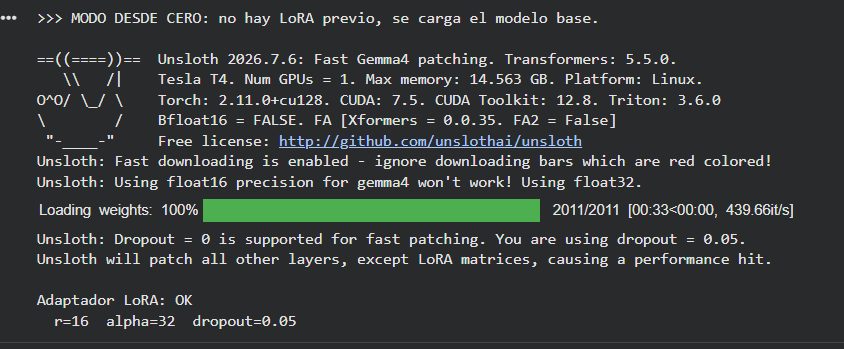

Ahora utilizando la data en JSON con y los nombres de las imagenes preparamos los textos de inferencia para cada imagen

In [ ]:
from PIL import Image, ImageOps

INSTRUCCION = (
    "Extrae de esta factura los siguientes campos y responde ÚNICAMENTE con un JSON válido, "
    "sin texto adicional: ruc (11 dígitos), fecha_emision (YYYY-MM-DD), "
    "numero_factura (tal cual aparece), monto_total (2 decimales, sin símbolo de moneda)."
)

# Por si el JSON trae los campos sueltos en vez de una clave 'respuesta' ya armada
MAPEO_CAMPOS = {
    'ruc':            ['ruc', 'RUC'],
    'fecha_emision':  ['fecha_emision', 'Fecha_Emisión', 'Fecha_Emision', 'fecha'],
    'numero_factura': ['numero_factura', 'Num_factura', 'numero'],
    'monto_total':    ['monto_total', 'Total', 'total', 'monto'],
}

def obtener_respuesta(ej):
    if 'respuesta' in ej:
        return ej['respuesta']
    salida = {}
    for destino, posibles in MAPEO_CAMPOS.items():
        clave = next((k for k in posibles if k in ej), None)
        if clave is None:
            raise KeyError(f"No encuentro '{destino}'. Claves del registro: {list(ej.keys())}")
        salida[destino] = str(ej[clave])
    return json.dumps(salida, ensure_ascii=False)

def cargar_imagen(ruta):
    img = Image.open(ruta)
    img = ImageOps.exif_transpose(img)
    img = img.convert("RGB")
    if RECORTE_SUPERIOR < 1.0:
        w, h = img.size
        img = img.crop((0, 0, w, int(h * RECORTE_SUPERIOR)))
    img.thumbnail((RESOLUCION, RESOLUCION))
    return img

def formatear(ej):
    img = cargar_imagen(Path(RUTA_IMAGENES, ej[CLAVE_IMG]))
    return {"messages": [
        {"role": "user", "content": [
            {"type": "image", "image": img},
            {"type": "text",  "text": ej.get('instruccion', INSTRUCCION)},
        ]},
        {"role": "assistant", "content": [
            {"type": "text", "text": obtener_respuesta(ej)},
        ]},
    ]}

dataset_formateado = [formatear(e) for e in datos]

print("Ejemplos formateados:", len(dataset_formateado))
print("Tamaño de la primera imagen:", dataset_formateado[0]["messages"][0]["content"][0]["image"].size)
print("\nRespuesta esperada del primer ejemplo:")
print(dataset_formateado[0]["messages"][1]["content"][0]["text"])

ahora vamos a generar de forma aleatorio una muestra para entrenar y otra para validar

In [ ]:
import random

random.seed(SEMILLA)
indices = list(range(len(dataset_formateado)))
random.shuffle(indices)

n_val = max(5, len(indices) // 5)          # ~20% para validación
idx_val, idx_train = indices[:n_val], indices[n_val:]

train_dataset = [dataset_formateado[i] for i in idx_train]
val_dataset   = [dataset_formateado[i] for i in idx_val]

print(f"Train: {len(train_dataset)} | Validación: {len(val_dataset)}")